# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Juan Sebastian Diaz Campos, 2026

# 04_modelo

En esta plantilla entregada por el profesor Diego Fernando Marin se llevará a cabo el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [166]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from prophet.serialize import model_to_json
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [167]:
cwd = os.getcwd() # current working directory
trusted_dir = cwd + '/../data/trusted/'
surface_dir = cwd + '/../data/surface/'

In [168]:
df = pd.read_csv(trusted_dir + 'datos_limpios_ml.csv', parse_dates=["Fecha_apertura", "Fecha_cierre"])

## Diseñar el Modelo

In [169]:
## Construyendo Modelo con prónostico Diario
serie_diaria = (df.groupby(pd.Grouper(key="Fecha_apertura", freq="D")).size().reset_index(name="y"))
serie_diaria.rename(columns={"Fecha_apertura": "ds"},inplace=True)
serie_diaria.head()

,ds,y
0,2024-05-06,2
1,2024-05-07,0
2,2024-05-08,5
3,2024-05-09,1
4,2024-05-10,6


In [170]:
## Construyendo Modelo con prónostico Semanal
serie_semanal = (df.groupby(pd.Grouper(key="Fecha_apertura", freq="W")).size().reset_index(name="y"))
serie_semanal.rename(columns={"Fecha_apertura": "ds"},inplace=True)
serie_semanal.head()

,ds,y
0,2024-05-12,14
1,2024-05-19,37
2,2024-05-26,30
3,2024-06-02,36
4,2024-06-09,41


### ¿Qué frecuencia presenta un comportamiento más estable para el entrenamiento?

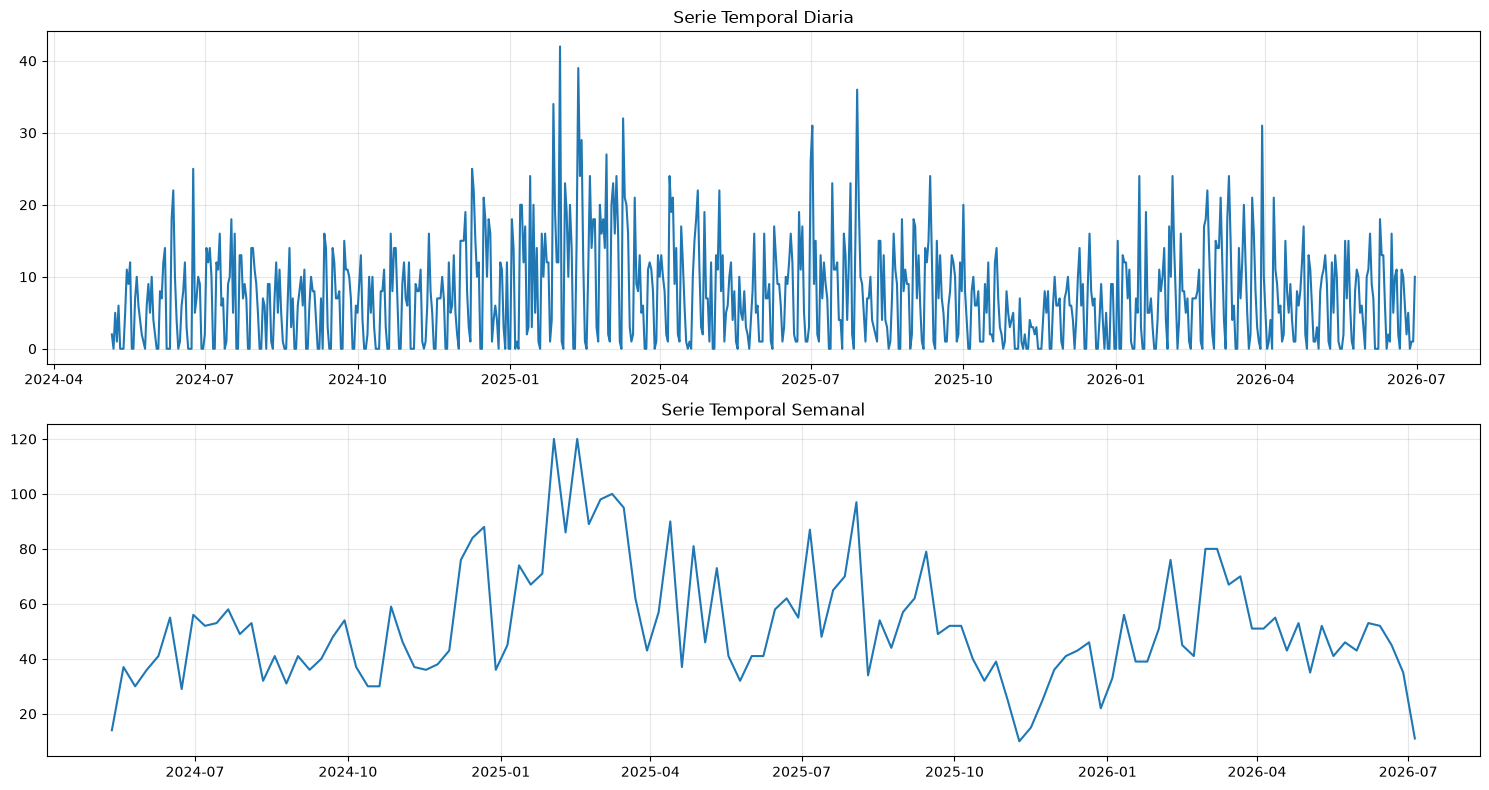

In [171]:
fig, ax = plt.subplots(2, 1, figsize=(15,8), sharex=False)

ax[0].plot(serie_diaria["ds"],serie_diaria["y"])
ax[0].set_title("Serie Temporal Diaria")
ax[0].grid(alpha=0.3)

ax[1].plot(serie_semanal["ds"],serie_semanal["y"])
ax[1].set_title("Serie Temporal Semanal")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparación Estadística

In [172]:
resumen = pd.DataFrame({
    "Frecuencia":[
        "Diaria",
        "Semanal"
    ],
    "Observaciones":[
        len(serie_diaria),
        len(serie_semanal)
    ],
    "Promedio":[
        serie_diaria["y"].mean(),
        serie_semanal["y"].mean()
    ],
    "DesvStd":[
        serie_diaria["y"].std(),
        serie_semanal["y"].std()
    ],
    "Mínimo":[
        serie_diaria["y"].min(),
        serie_semanal["y"].min()
    ],
    "Máximo":[
        serie_diaria["y"].max(),
        serie_semanal["y"].max()
    ]
})

resumen

,Frecuencia,Observaciones,Promedio,DesvStd,Mínimo,Máximo
0,Diaria,786,7.477099,6.902422,0,42
1,Semanal,113,52.008850,21.342235,10,120


In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5877 entries, 0 to 5876
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_caso                 5877 non-null   str           
 1   Fecha_apertura          5877 non-null   datetime64[us]
 2   Fecha_cierre            5877 non-null   datetime64[us]
 3   Prioridad               5877 non-null   str           
 4   Estado                  5877 non-null   str           
 5   Titulo_caso             5877 non-null   str           
 6   Responsable_atencion    5877 non-null   str           
 7   Aplicacion              5877 non-null   str           
 8   Sitio                   5877 non-null   str           
 9   Tipo_solicitud_1        5877 non-null   str           
 10  Tipo_dia_apertura       5877 non-null   str           
 11  Tipo_dia_cierre         5877 non-null   str           
 12  Nro_dia_apertura        5877 non-null   int64         
 13 

In [174]:
print(df["Fecha_apertura"].min())
print(df["Fecha_apertura"].max())
print(len(df))

2024-05-06 14:12:53
2026-06-30 15:48:23
5877


In [175]:
serie_diaria["y"].describe()

count    786.000000
mean       7.477099
std        6.902422
min        0.000000
25%        1.000000
50%        7.000000
75%       12.000000
max       42.000000
Name: y, dtype: float64

In [176]:
serie_semanal["y"].describe()

count    113.000000
mean      52.008850
std       21.342235
min       10.000000
25%       38.000000
50%       48.000000
75%       62.000000
max      120.000000
Name: y, dtype: float64

In [177]:
(serie_diaria["y"] == 0).sum()

np.int64(154)

### Decisión de frecuencia y variables complementarias

Según la conclusión del EDA (`03_EDA.ipynb`), la variable objetivo del proyecto es la **cantidad de solicitudes abiertas por día**. Por lo tanto, la **serie diaria** será el modelo de producción; la serie semanal se conserva únicamente como comparación de referencia (agregación con menor varianza relativa, pero de menor utilidad operativa para el negocio).

El EDA también identificó el **tipo de día (hábil/festivo)** como variable relevante para complementar el modelo. Se incorpora como *regresor externo* de Prophet, calculado con la misma librería `holidays` (calendario de Colombia) ya utilizada en `02_limpieza.ipynb`, manteniendo consistencia entre etapas del proyecto.

In [178]:
festivos_colombia = holidays.Colombia(
    years=range(serie_diaria["ds"].dt.year.min(), serie_diaria["ds"].dt.year.max() + 1)
)

def es_dia_habil(fecha):
    if fecha.weekday() >= 5:
        return 0
    if fecha.date() in festivos_colombia:
        return 0
    return 1

serie_diaria["es_habil"] = serie_diaria["ds"].apply(es_dia_habil)
serie_diaria.head()

,ds,y,es_habil
0,2024-05-06,2,1
1,2024-05-07,0,1
2,2024-05-08,5,1
3,2024-05-09,1,1
4,2024-05-10,6,1


## Entrenar el Modelo

In [179]:
def entrenar_prophet(serie, regresores=None):
    regresores = regresores or []
    train_size = int(len(serie) * 0.8)
    train = serie.iloc[:train_size].copy()
    test = serie.iloc[train_size:].copy()
    train["ds"] = pd.to_datetime(train["ds"]).astype("datetime64[ns]")

    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05
    )
    for regresor in regresores:
        modelo.add_regressor(regresor)

    modelo.fit(train[["ds", "y"] + regresores])
    future = test[["ds"] + regresores]
    forecast = modelo.predict(future)

    # La cantidad de solicitudes no puede ser negativa: se recorta en 0.
    forecast["yhat"] = forecast["yhat"].clip(lower=0)
    forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)

    return modelo, train, test, forecast

In [180]:
modelo_diario, train_d, test_d, forecast_d = entrenar_prophet(serie_diaria, regresores=["es_habil"])

23:15:39 - cmdstanpy - INFO - Chain [1] start processing
23:15:39 - cmdstanpy - INFO - Chain [1] done processing


In [181]:
modelo_semanal,train_s,test_s,forecast_s = entrenar_prophet(serie_semanal)

23:15:40 - cmdstanpy - INFO - Chain [1] start processing
23:15:40 - cmdstanpy - INFO - Chain [1] done processing


## Verificar el Modelo - Hacer Pruebas

In [182]:
def evaluar(test,forecast):

    mae = mean_absolute_error(

        test["y"],

        forecast["yhat"]

    )

    rmse = np.sqrt(

        mean_squared_error(

            test["y"],

            forecast["yhat"]

        )

    )

    return mae,rmse

In [183]:
mae_d,rmse_d = evaluar(test_d,forecast_d)

mae_s,rmse_s = evaluar(test_s,forecast_s)

In [184]:
comparacion = pd.DataFrame({

    "Modelo":[

        "Prophet Diario",

        "Prophet Semanal"

    ],

    "MAE":[

        round(mae_d,2),

        round(mae_s,2)

    ],

    "RMSE":[

        round(rmse_d,2),

        round(rmse_s,2)

    ]

})

comparacion

,Modelo,MAE,RMSE
0,Prophet Diario,4.12,6.00
1,Prophet Semanal,36.37,39.33


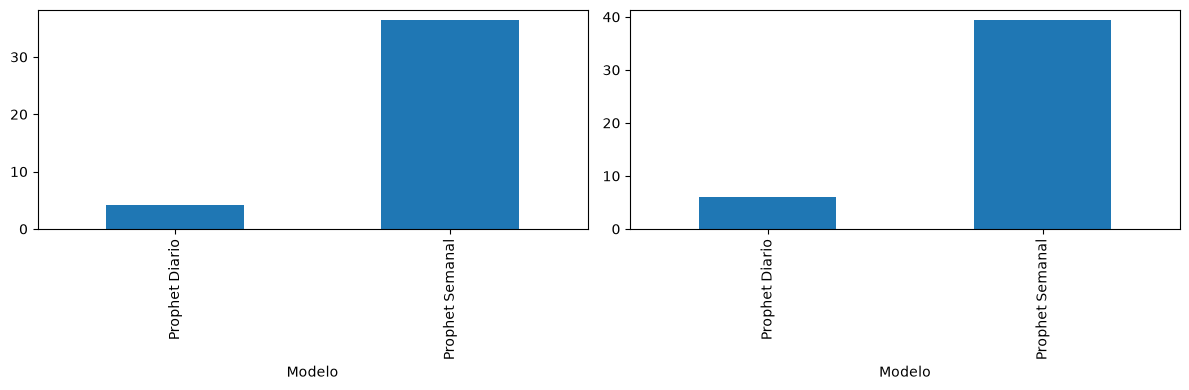

In [185]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

comparacion.plot.bar(

    x="Modelo",

    y="MAE",

    ax=ax[0],

    legend=False

)

comparacion.plot.bar(

    x="Modelo",

    y="RMSE",

    ax=ax[1],

    legend=False

)

plt.tight_layout()

plt.show()

In [186]:
comparacion_diaria = test_d[["ds", "y"]].copy()
comparacion_diaria["Prediccion"] = forecast_d["yhat"].values
comparacion_diaria.head()

,ds,y,Prediccion
628,2026-01-24,0,2.304336
629,2026-01-25,0,2.084014
630,2026-01-26,4,9.617023
631,2026-01-27,11,9.036355
632,2026-01-28,8,8.879950


In [187]:
mae_final = mean_absolute_error(comparacion_diaria["y"], comparacion_diaria["Prediccion"])

rmse_final = np.sqrt(mean_squared_error(comparacion_diaria["y"], comparacion_diaria["Prediccion"]))

# El MAPE clásico se indefine cuando hay días con 0 solicitudes reales (154 de 786 días).
# Se usa sMAPE (simétrico, acotado entre 0% y 200%) como alternativa robusta.
denominador = (comparacion_diaria["y"].abs() + comparacion_diaria["Prediccion"].abs()).replace(0, np.nan)
smape_final = (
    2 * (comparacion_diaria["y"] - comparacion_diaria["Prediccion"]).abs() / denominador
).mean() * 100

In [188]:
metricas = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "sMAPE (%)"],
    "Valor": [
        round(mae_final, 2),
        round(rmse_final, 2),
        round(smape_final, 2)
    ]
})

metricas

,Métrica,Valor
0,MAE,4.12
1,RMSE,6.00
2,sMAPE (%),89.26


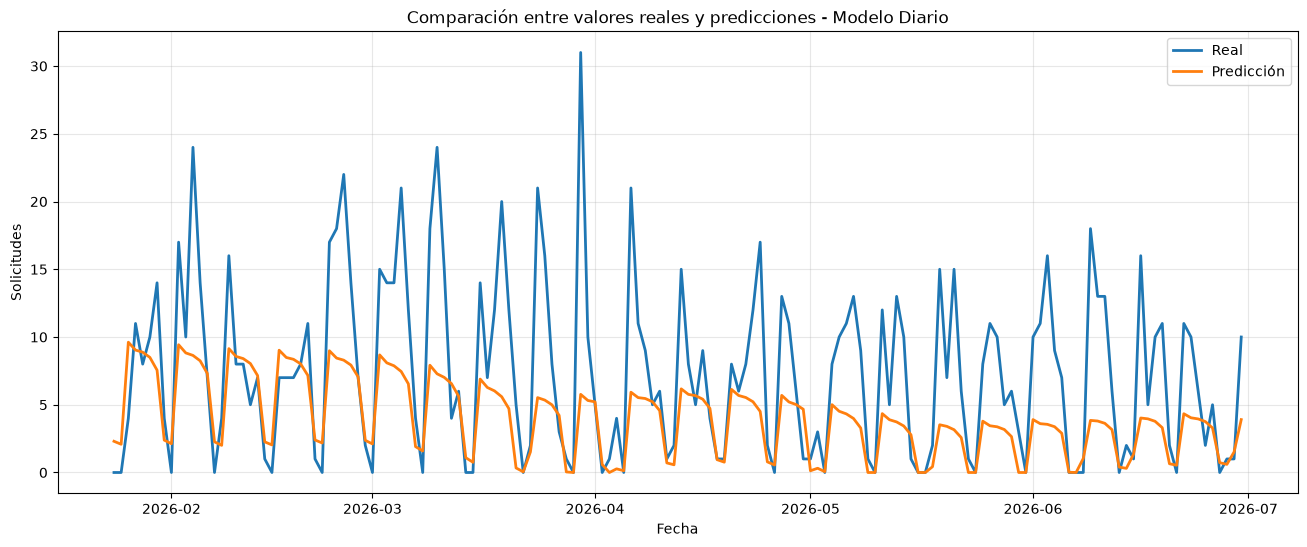

In [189]:
plt.figure(figsize=(16, 6))

plt.plot(
    comparacion_diaria["ds"],
    comparacion_diaria["y"],
    label="Real",
    linewidth=2
)

plt.plot(
    comparacion_diaria["ds"],
    comparacion_diaria["Prediccion"],
    label="Predicción",
    linewidth=2
)

plt.title("Comparación entre valores reales y predicciones - Modelo Diario")
plt.xlabel("Fecha")
plt.ylabel("Solicitudes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Análisis de residuales

Verificar que el error (real - predicción) no tenga sesgo sistemático ni patrones remanentes en el tiempo.

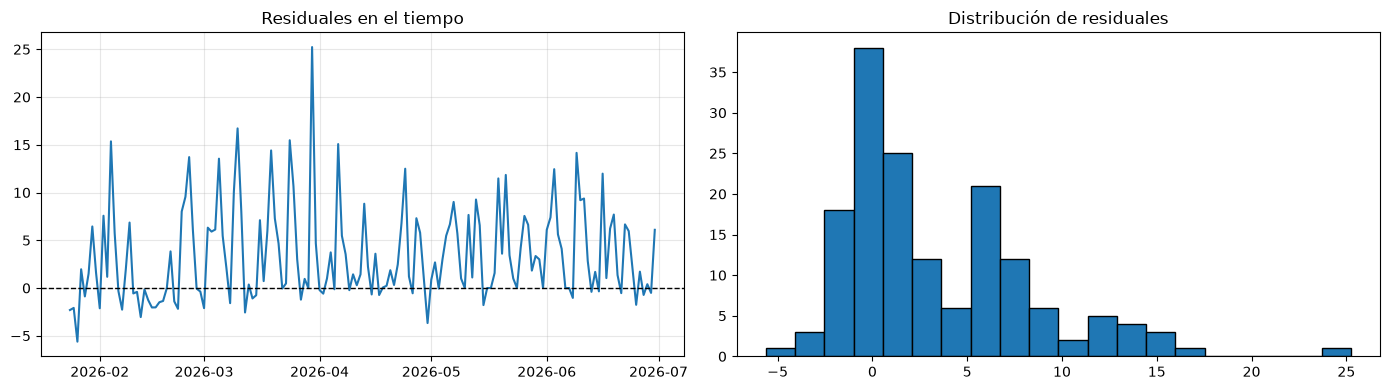

Residual promedio: 3.42 (cercano a 0 indica ausencia de sesgo sistemático)


In [190]:
residuales = comparacion_diaria["y"] - comparacion_diaria["Prediccion"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(comparacion_diaria["ds"], residuales)
ax[0].axhline(0, color="black", linewidth=1, linestyle="--")
ax[0].set_title("Residuales en el tiempo")
ax[0].grid(alpha=0.3)

ax[1].hist(residuales, bins=20, edgecolor="black")
ax[1].set_title("Distribución de residuales")

plt.tight_layout()
plt.show()

print(f"Residual promedio: {residuales.mean():.2f} (cercano a 0 indica ausencia de sesgo sistemático)")

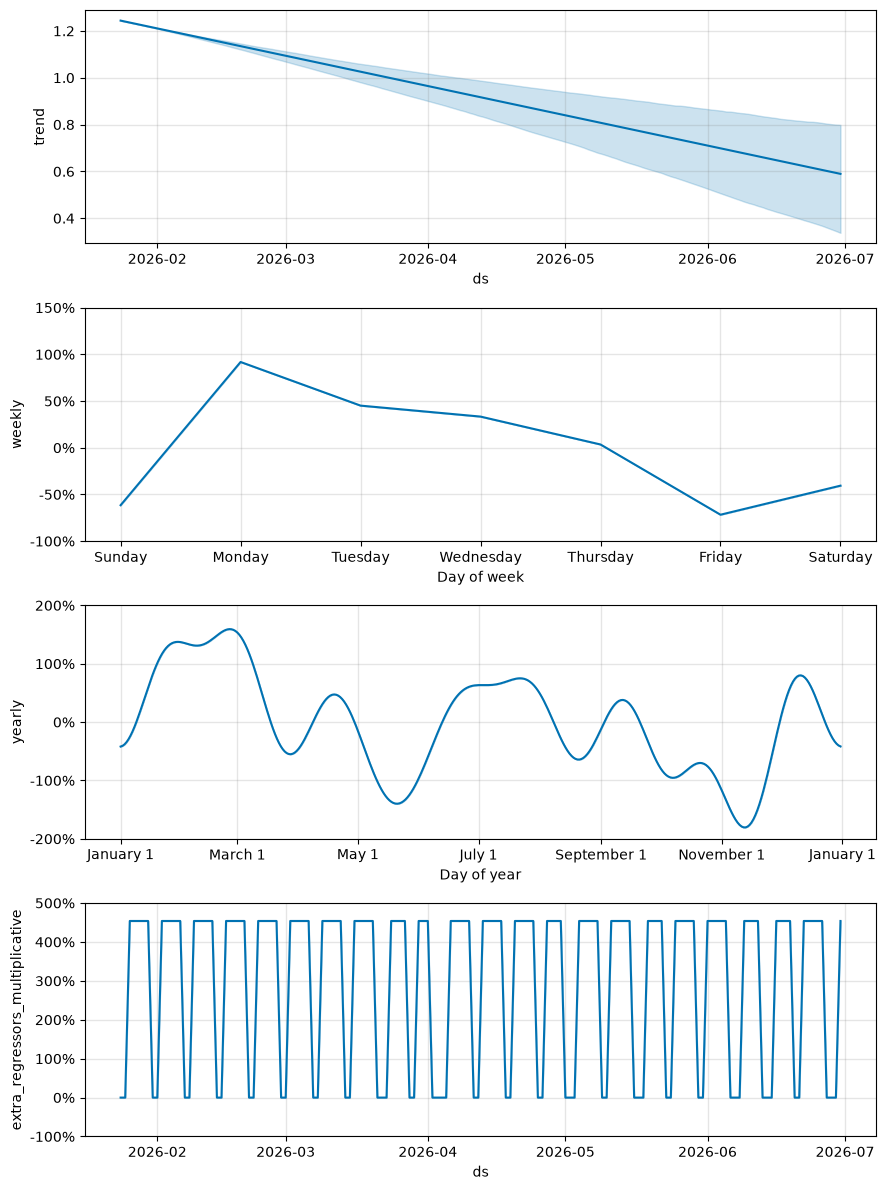

In [191]:
modelo_diario.plot_components(forecast_d)
plt.show()

### Modelo final para el pronóstico futuro

`modelo_diario` se entrenó únicamente con el 80% inicial del histórico (hasta ~2026-01-23) para poder validarlo contra un conjunto de prueba real, con los resultados evaluados arriba. Para proyectar los próximos 30 días **a partir de la última fecha disponible del histórico (2026-06-30)**, se reentrena Prophet con el 100% de los datos, usando los mismos hiperparámetros y el regresor `es_habil` ya validados.

In [192]:
modelo_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05
)
modelo_final.add_regressor("es_habil")
modelo_final.fit(serie_diaria[["ds", "y", "es_habil"]])

23:15:53 - cmdstanpy - INFO - Chain [1] start processing
23:15:53 - cmdstanpy - INFO - Chain [1] done processing


In [193]:
future = modelo_final.make_future_dataframe(periods=30, freq="D")

In [194]:
festivos_futuro = holidays.Colombia(
    years=range(future["ds"].dt.year.min(), future["ds"].dt.year.max() + 1)
)

def es_dia_habil_futuro(fecha):
    if fecha.weekday() >= 5:
        return 0
    if fecha.date() in festivos_futuro:
        return 0
    return 1

future["es_habil"] = future["ds"].apply(es_dia_habil_futuro)
forecast_futuro = modelo_final.predict(future)

# La cantidad de solicitudes no puede ser negativa: se recorta en 0.
forecast_futuro["yhat"] = forecast_futuro["yhat"].clip(lower=0)
forecast_futuro["yhat_lower"] = forecast_futuro["yhat_lower"].clip(lower=0)

# Prophet reutiliza el nombre "es_habil" en el forecast para la contribución del regresor,
# por lo que se guarda el indicador original (0/1) en una columna aparte para reportes.
forecast_futuro["dia_habil"] = future["es_habil"].values

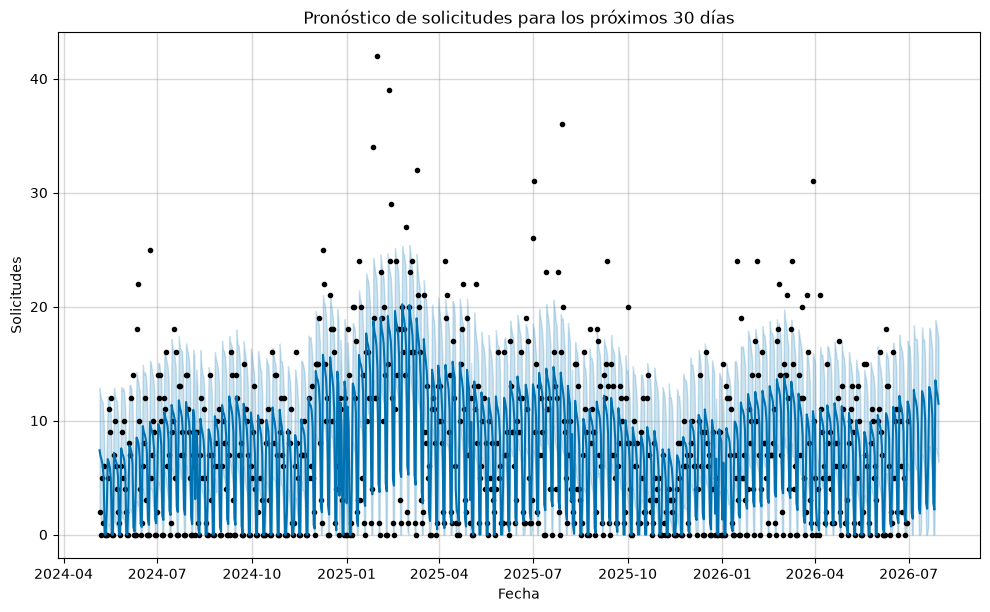

In [195]:
fig = modelo_final.plot(forecast_futuro)
plt.title("Pronóstico de solicitudes para los próximos 30 días")
plt.xlabel("Fecha")
plt.ylabel("Solicitudes")
plt.grid(alpha=0.3)
plt.show()

In [196]:
forecast_futuro[["ds", "yhat", "yhat_lower", "yhat_upper", "dia_habil"]].tail()

,ds,yhat,yhat_lower,yhat_upper,dia_habil
811,2026-07-26,2.187537,0.000000,7.250409,0
812,2026-07-27,13.532523,7.604930,18.838014,1
813,2026-07-28,12.723855,7.411351,18.355777,1
814,2026-07-29,12.229053,6.909119,17.775303,1
815,2026-07-30,11.477181,6.363334,17.056939,1


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

In [197]:
# Modelo serializado en formato oficial de Prophet (portable entre versiones)
with open(surface_dir + "modelo_prophet_diario.json", "w") as f:
    f.write(model_to_json(modelo_final))

# Insumos para el Dashboard/Producto de Datos, listos para leer sin recargar el modelo
forecast_futuro[["ds", "yhat", "yhat_lower", "yhat_upper", "dia_habil"]].to_csv(surface_dir + "pronostico_30d.csv", index=False)
metricas.to_csv(surface_dir + "metricas_finales_modelo.csv", index=False)

print("Modelo guardado en 'data/surface/' como un archivo JSON")
print("Datos de apoyo guardados en 'data/surface/'...")

Modelo guardado en 'data/surface/' como un archivo JSON
Datos de apoyo guardados en 'data/surface/'...


**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
